In [1]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

I'm going to find out whether using all genes or only hvgs file give better cell type annotation results

I use the same criteria of markers for both adrenal and tumor samples

all the cell type markers in literature for cell type annotation

In [2]:
steroidogenic_markers = ["NR5A1", "CYP11B1", "CYP11B2", "CYP11A1", "CYP17A1", "STAR", "OYP17A1", "CYP19A1"]
capsular_markers = ["TCF21", "RSPO3", "WT1", "GATA4", "NPY", "CHGA", "PIK3C2A", "SLC12A2", "P2RY1", "NTRK1", "SLC18A1"]
chromaffin_markers = ["TH", "CHGA", "CHGB", "DBH", "HMX1", "NTRK1", "PHOX2B", "PHOX2A", "NPY", "PIK3C2A", "SLC12A2", "P2RY1", "SLC18A1", "DDC", "PNMT", "ELAVL3", "ELAVL4", "PENK", "ADM", "DLK1", "SLC35D3", "INSMI"]
sympathoblasts_markers = ["CARTPT", "INSM1", "DBH", "CHGA", "TH", "GAP43", "BCL2", "NPY", "PIK3C2A", "SLC12A2", "P2RY1", "NTRK1", "SLC18A1", "NEFM", "STMN2", "SYN3", "ALK", "PRPH", "ISL1", "STMN4", "ELAVL2", "HAND2"]
fibroblasts_markers = ["DCN", "TAGLN", "COL3A1", "COL1A1", "COL6A1"]
SCPs_markers = ["SOX10", "PLP1", "MPZ", "FABP7", "FOXD3", "ERBB3", "CDH19", "EDNRB", "SPARC", "S100B", "NGFR", "MBP", "COL2A1", "POSTN", "MOXD1", "GAS7"]
myeloid_markers = ["CD14", "CD68", "AIF1", "CSF1R", "TYROBP", "FCER1G"]
T_markers = ["CD2", "CD3D", "CD3E", "CD3G", "CD7", "CD52"]
NE_markers = ["PHOX2B", "PHOX2A", "TH", "SYP", "CHGA", "CHGB", "DBH", "GATA2"]
pDC_markers = ["IL3RA", "CLEC4C"]
schwann_stromal_markers = ["SOX10", "S100B"]
B_markers = ["CD79A", "CD79B", "CD19", "MS4A1", "CD52"]
endothelium_markers = ["ENG", "CLDN5", "VMF", "CDH5"]
neuroblastoma_markers = ["PHOX2B", "PHOX2A", "MYCN"]

take a look at how markers of different (but similar) cell types overlap

In [3]:
# for chromaffin cells, sympathoblasts and NE
chromaffin_sympathoblasts_markers = [i for i in set(chromaffin_markers).intersection(set(sympathoblasts_markers))]
chromaffin_exclusive_markers = [i for i in chromaffin_markers if i not in chromaffin_sympathoblasts_markers]
sympathoblasts_exclusive_markers = [i for i in sympathoblasts_markers if i not in chromaffin_sympathoblasts_markers]
print(chromaffin_sympathoblasts_markers)
print(chromaffin_exclusive_markers)
print(sympathoblasts_exclusive_markers)

['SLC18A1', 'NPY', 'NTRK1', 'TH', 'SLC12A2', 'CHGA', 'DBH', 'P2RY1', 'PIK3C2A']
['CHGB', 'HMX1', 'PHOX2B', 'PHOX2A', 'DDC', 'PNMT', 'ELAVL3', 'ELAVL4', 'PENK', 'ADM', 'DLK1', 'SLC35D3', 'INSMI']
['CARTPT', 'INSM1', 'GAP43', 'BCL2', 'NEFM', 'STMN2', 'SYN3', 'ALK', 'PRPH', 'ISL1', 'STMN4', 'ELAVL2', 'HAND2']


cell cycle markers

In [4]:
cell_cycle_markers = ["MKI67", "CENPF", "TOP2A", "UBE2C", "CDK1", "TUBB4B"]
G2M_phase_markers = ["MKI67", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "TOP2A", "NDC80", "CKS2", "NUF2"]
S_phase_markers = ["MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2", "MCM6"]

cell properties markers

In [5]:
NCC_like_markers = ["NR3C1", "BHLHE41", "MAFF", "GLIS3", "IRF1", "IRF2", "IRF3", "FLI1", "MEF2D", "PRRX1", "RUNX1", "RUNX2", "TBX18", "FOSL1", "FOSL2"]
noradrenergic_markers = ["PHOX2B", "GATA3", "HAND2", "HAND1", "KLF7", "ISL1", "PHOX2A"]
mesenchymal_markers = ["A2M", "ABRACL", "ACADVL", "ACAP2", "ACTA2", "ACTN1", "ADAM19", "ADAM9", "ADAMTS5", "ADGRE5"]
adrenergic_markers = ["ABCA3", "ABCB1", "ABLIM1", "ACOT7", "ACTL6B", "ACVR1B", "ADAM22", "ADCYAP1R1", "ADGRB3", "ADRBK2"]

using all genes

In [6]:
import scanpy as sc

add cell type annotation to logarithmic but unscaled data

In [7]:
cdata = sc.read_h5ad("raw.h5ad")
cdata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'scrublet'

In [8]:
# logarithmic data, not scaled yet
# this data is for later NE-reclustering, because selecting hvgs need log data,
# the data can't be scaled
# still, add all the annotations to log_data as usual, including cell type in this file
# but not clustering or umap, because I'll do reclustering shortly
log_data = sc.read_h5ad("log1p.h5ad")
log_data

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'scrublet'

add cell type annotation to scaled data

In [7]:
sdata = sc.read_h5ad("leiden.h5ad")
sdata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [8]:
# cdata.obs = ldata.obs # for "leiden"
# cdata.uns = ldata.uns  # for "umap"
# cdata.obsm = ldata.obsm  # for "X_umap"
# cdata.obsp = ldata.obsp
# cdata

In [9]:
sdata.obs["leiden"]

Cell_barcode
T44_AAACCTGAGAGGTTGC.1     1
T44_AAACCTGAGAGTGAGA.1     2
T44_AAACCTGAGGCATGTG.1     0
T44_AAACCTGAGTGTACCT.1     9
T44_AAACCTGCAATGCCAT.1     0
                          ..
T40_TTTGTCAGTGTCCTCT.1     4
T40_TTTGTCATCACTTATC.1     2
T40_TTTGTCATCAGGCCCA.1    10
T40_TTTGTCATCTGCAGTA.1     4
T40_TTTGTCATCTGGAGCC.1     4
Name: leiden, Length: 152182, dtype: category
Categories (30, object): ['0', '1', '2', '3', ..., '26', '27', '28', '29']

In [10]:
genes = sdata.var_names
cell_type_annotation_dict = {
    'Steroidogenic-cortical-cells': [marker for marker in steroidogenic_markers if marker in genes],
    'Capsular-cells': [marker for marker in capsular_markers if marker in genes],
    # 'Sympathoblast': [marker for marker in sympathoblasts_markers if marker in cdata.var_names],
    'SCPs': [marker for marker in SCPs_markers if marker in genes],
    # 'Chromaffin-cells': [marker for marker in chromaffin_markers if marker in cdata.var_names], 
    'T-cells': [marker for marker in T_markers if marker in genes],
    'B-cells': [marker for marker in B_markers if marker in genes],
    'Myeloid-cells': [marker for marker in myeloid_markers if marker in genes],
    'Fibroblasts': [marker for marker in fibroblasts_markers if marker in genes],
    'Endothelium': [marker for marker in endothelium_markers if marker in genes],
    'pDC': [marker for marker in pDC_markers if marker in genes],
    'Schwann-stromal-cells': [marker for marker in schwann_stromal_markers if marker in genes],
    'NE-cells': [marker for marker in NE_markers if marker in genes],
    'neuroblastoma': [marker for marker in neuroblastoma_markers if marker in genes],
    'Chromaffin-Sympathoblasts': [marker for marker in chromaffin_sympathoblasts_markers if marker in genes],
    'Chromaffin-cells-exclusive': [marker for marker in chromaffin_exclusive_markers if marker in genes],
    'Sympathoblasts-exclusive': [marker for marker in sympathoblasts_exclusive_markers if marker in genes]
}

categories: 0, 1, 2, etc.
var_group_labels: Steroidogenic-cortical-cells, Capsular-cells, SCPs, etc.


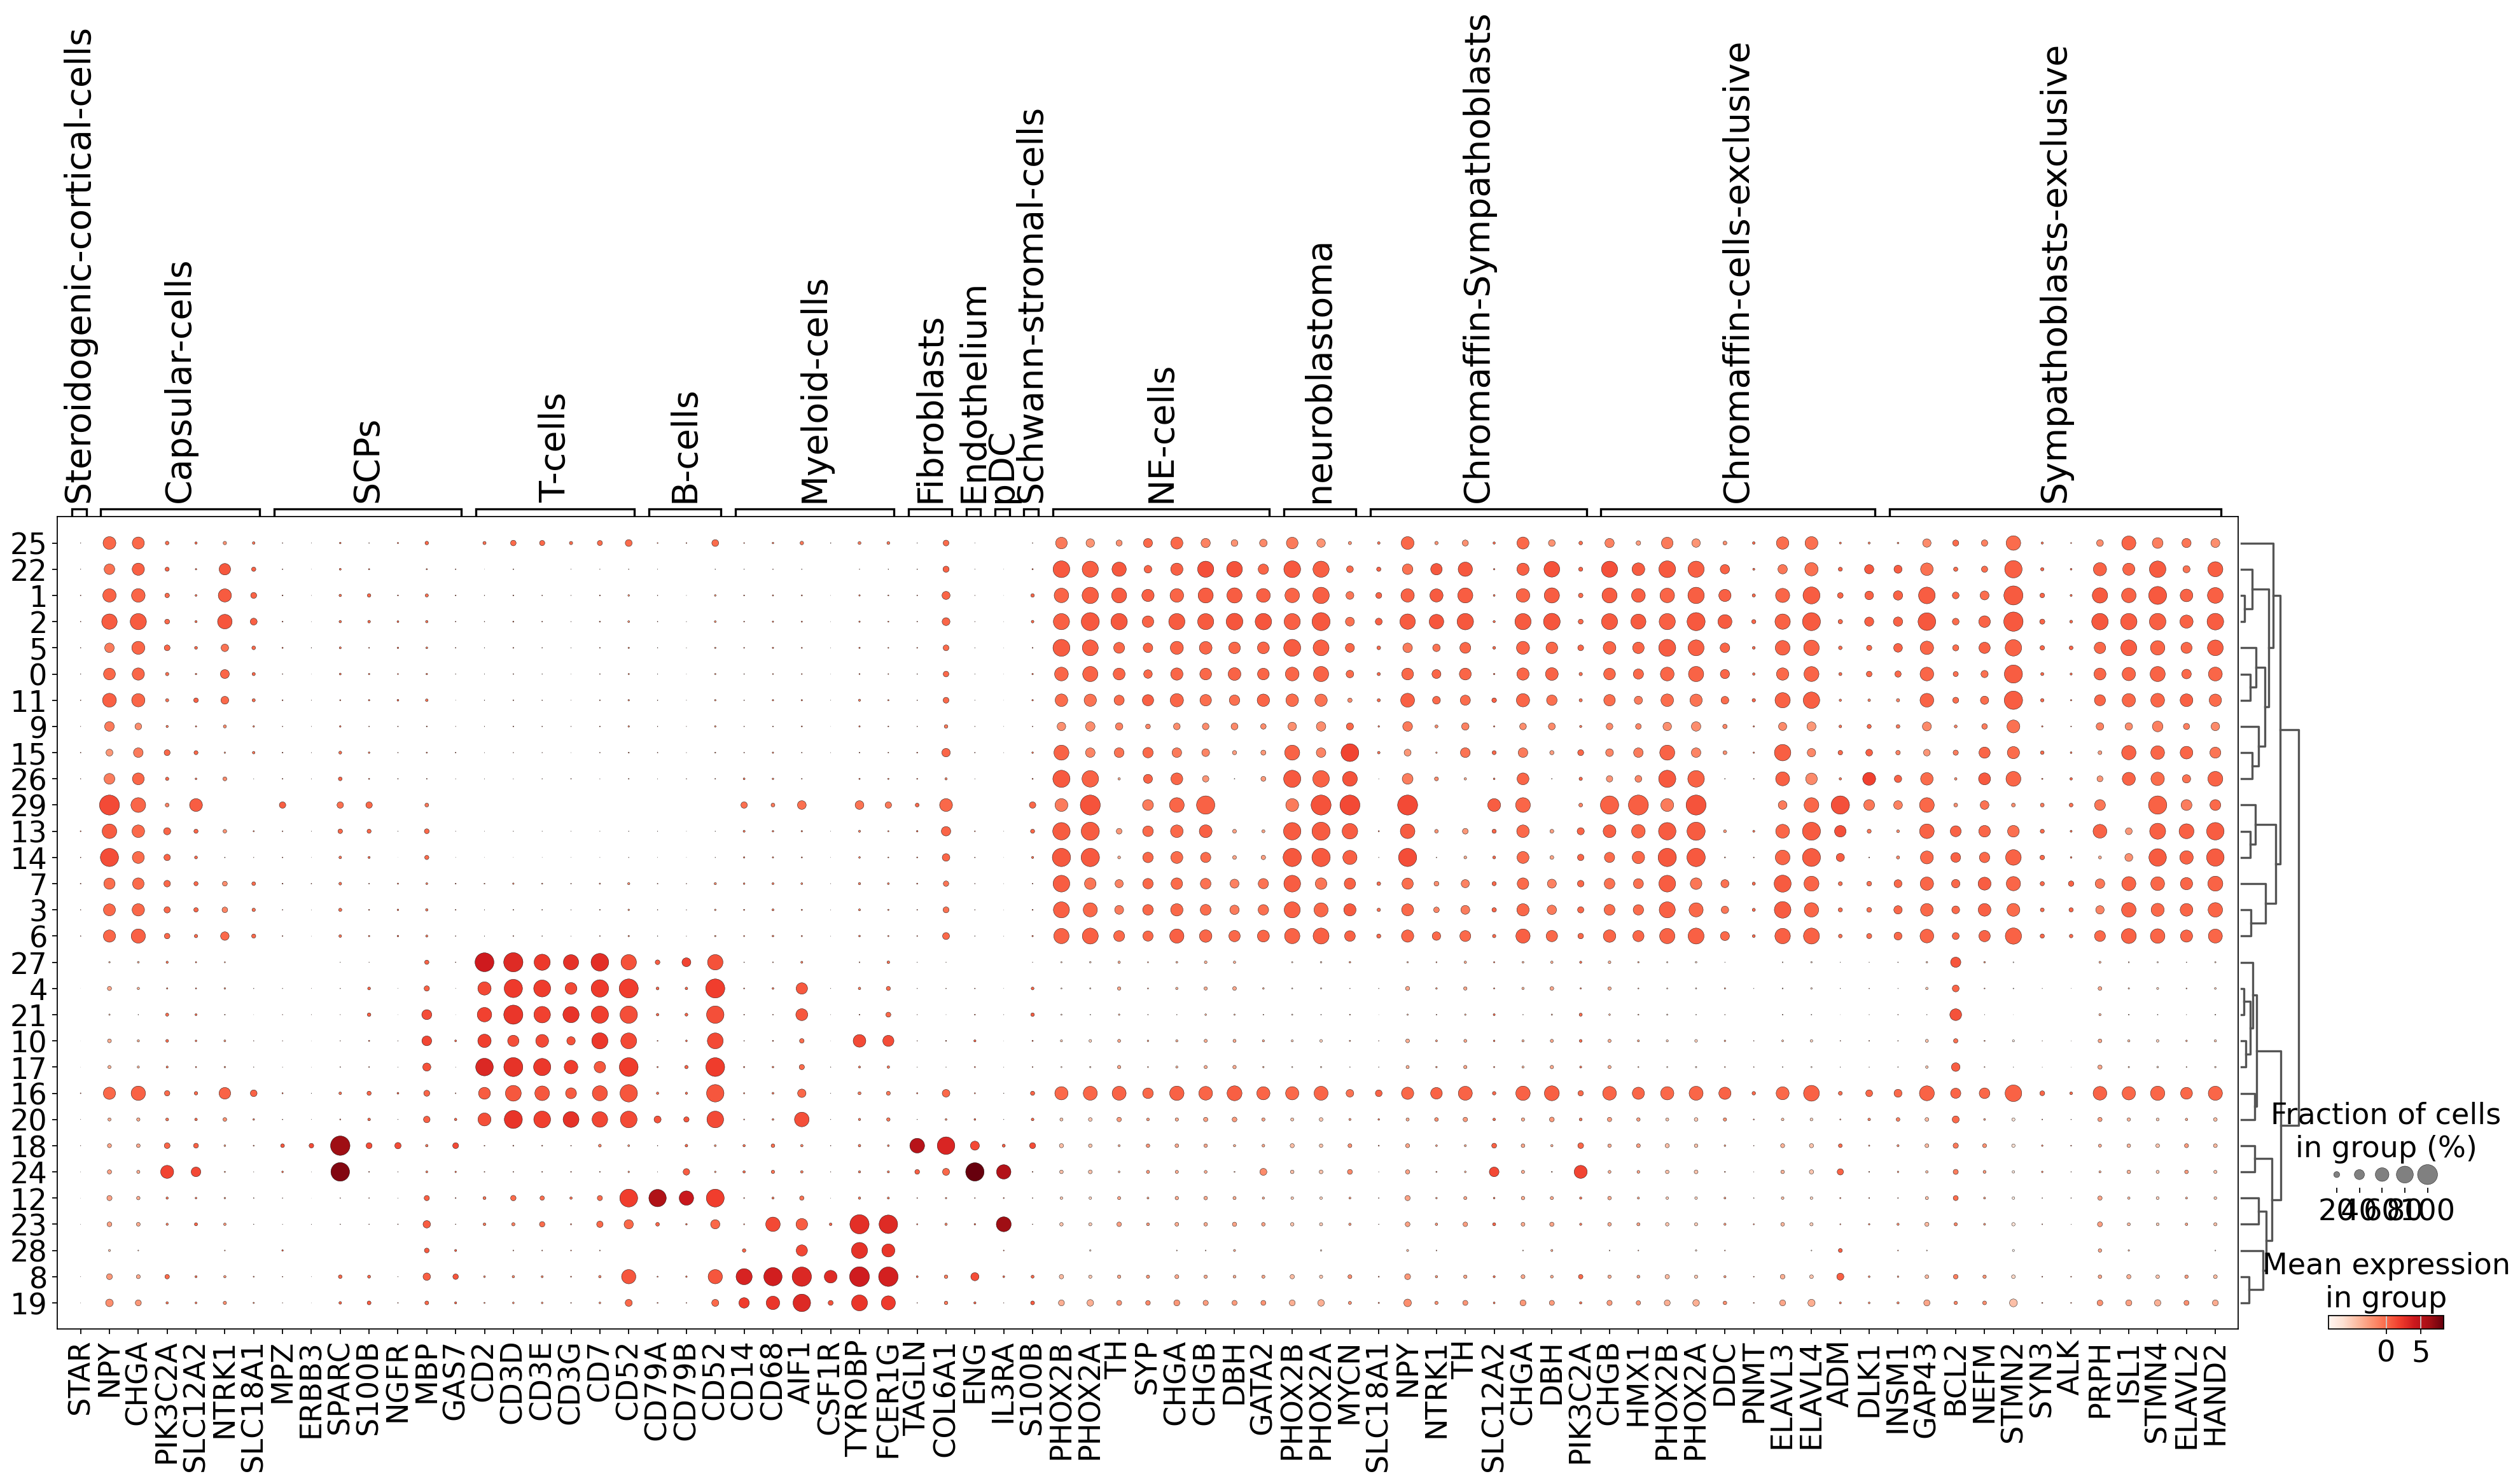

In [11]:
sc.set_figure_params(fontsize=25)
sc.pl.dotplot(sdata, var_names=cell_type_annotation_dict, groupby='leiden', use_raw=False, dendrogram=True, vcenter=0, save=".svg")

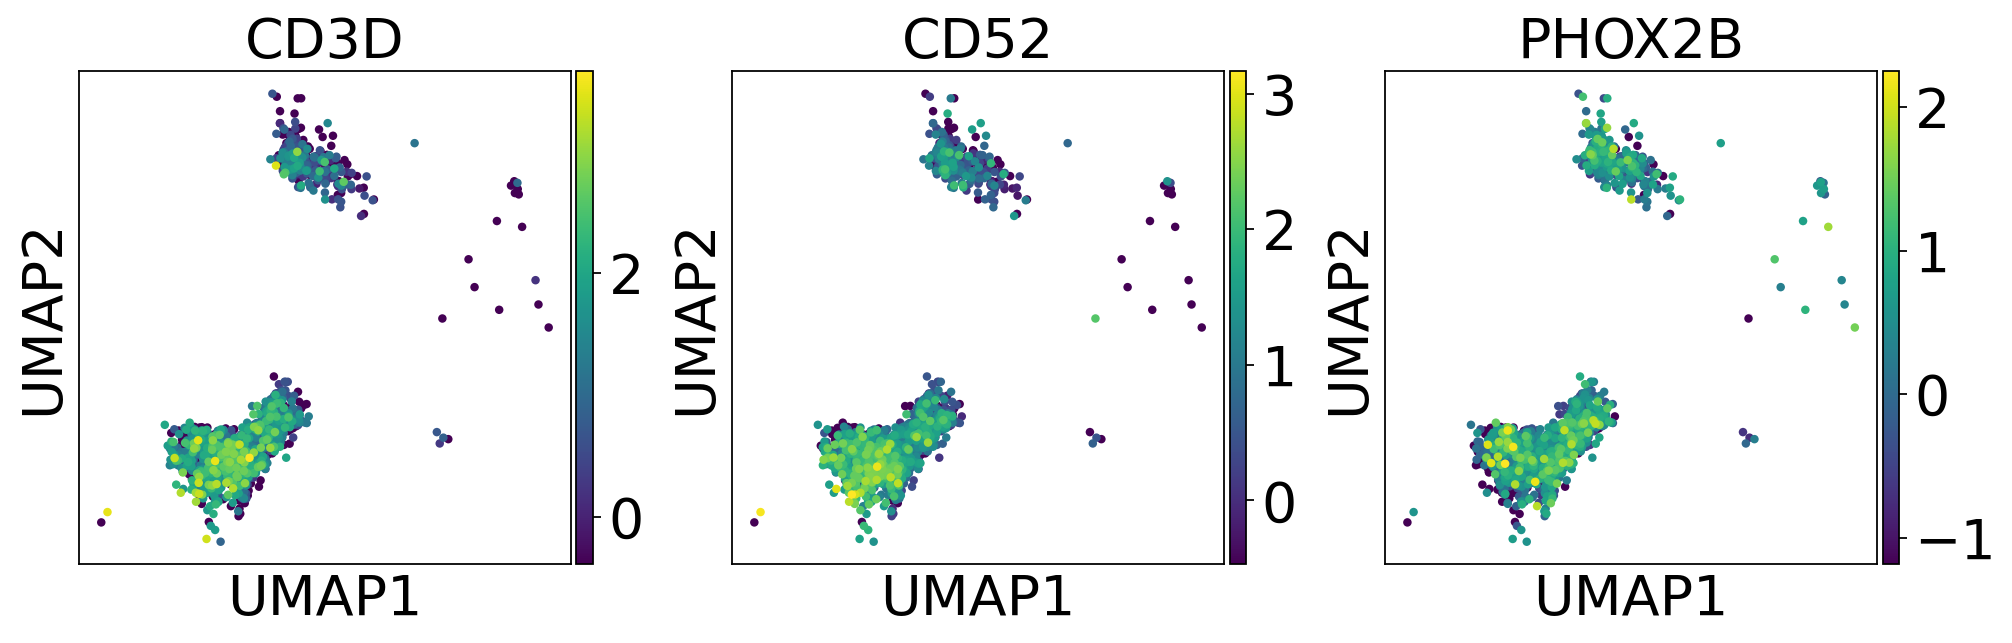

In [13]:
# observe doublets
sc.pl.umap(sdata[sdata.obs.leiden == '16'], color=["CD3D", "CD52", "PHOX2B"], legend_fontsize=10)

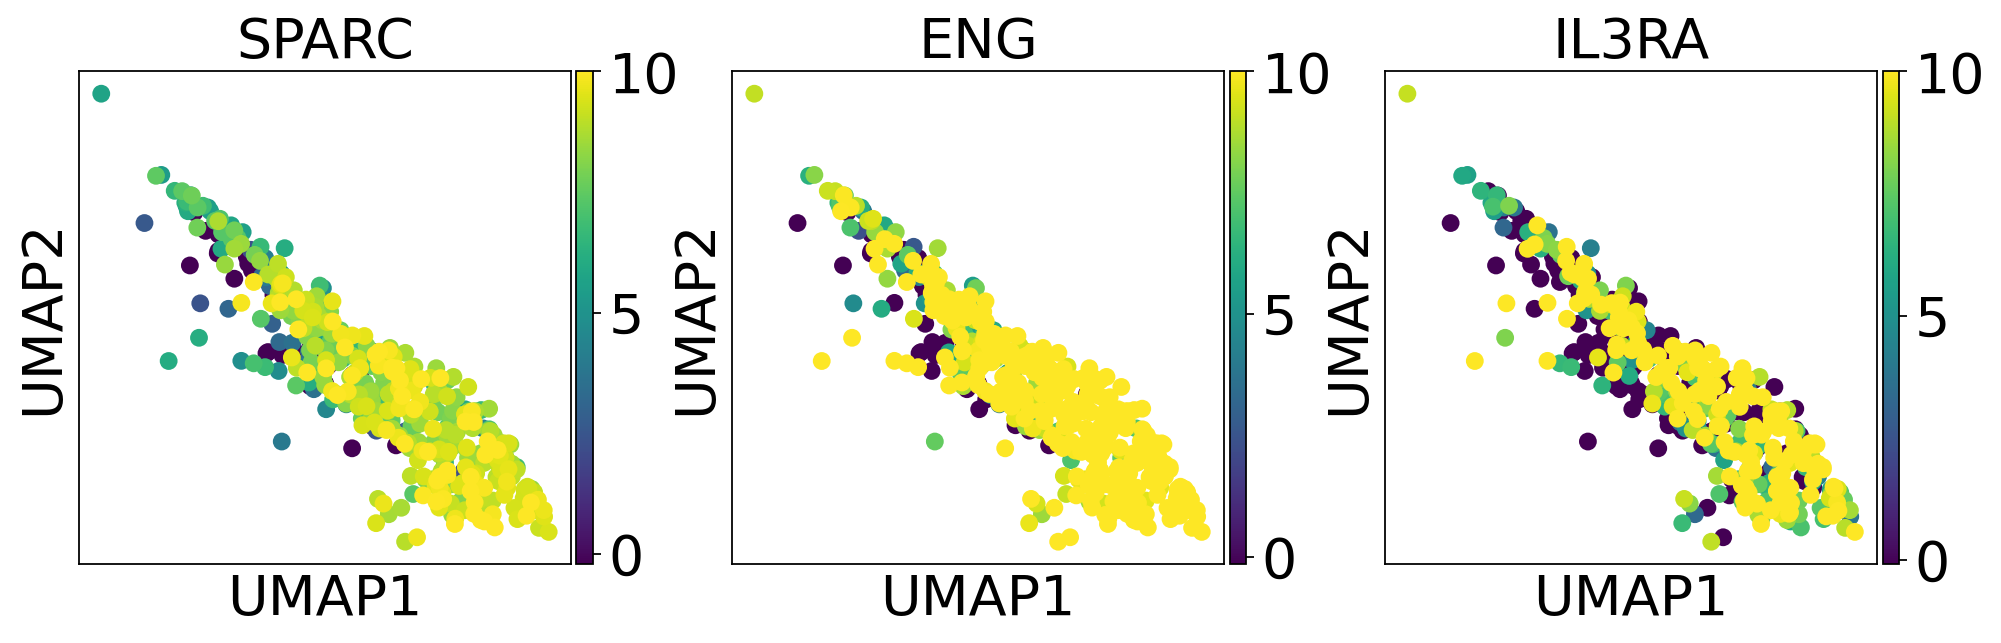

In [14]:
# observe doublets
sc.pl.umap(sdata[sdata.obs.leiden == '24'], color=["SPARC", "ENG", "IL3RA"], legend_fontsize=10)

look at cell cycle

In [15]:
cell_cycle_annotation_dict = {
    'cell-cycle': [marker for marker in cell_cycle_markers if marker in genes],
    'G2M-phase': [marker for marker in G2M_phase_markers if marker in genes],
    'S-phase': [marker for marker in S_phase_markers if marker in genes]
    }

categories: 0, 1, 2, etc.
var_group_labels: cell-cycle, G2M-phase, S-phase


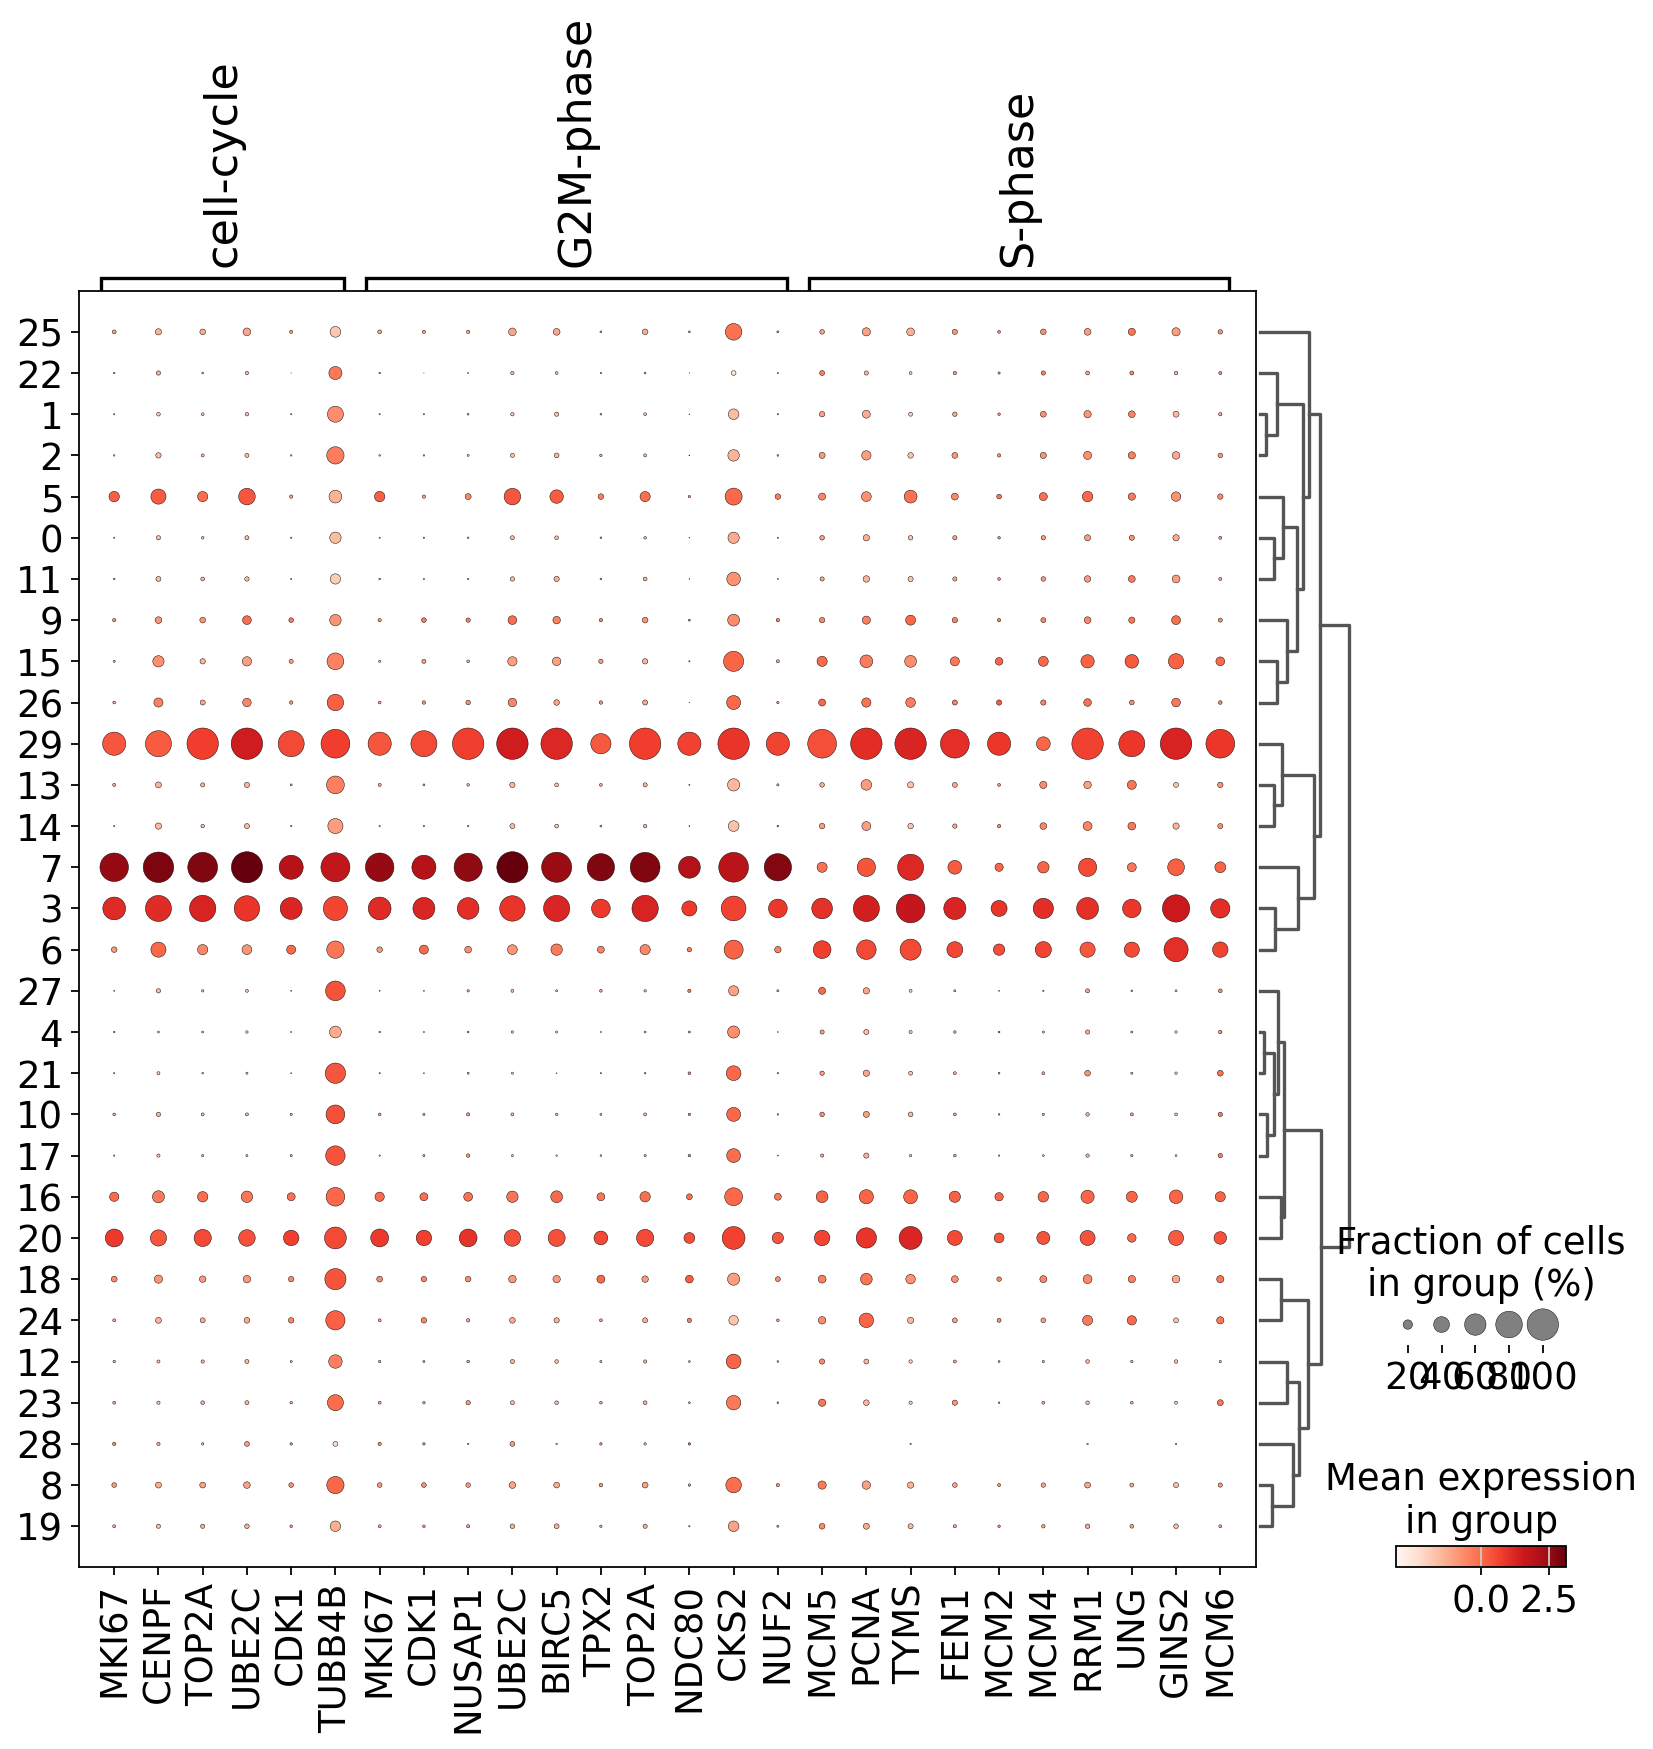

In [16]:
sc.set_figure_params(fontsize=20)
sc.pl.dotplot(sdata, var_names=cell_cycle_annotation_dict, groupby='leiden', use_raw=False, dendrogram=True, vcenter=0, save="_cell_cycle.svg")

look at cell properties

In [17]:
cell_properties_annotation_dict = {
    'NCC-like': [marker for marker in NCC_like_markers if marker in genes],
    'Noradrenergic': [marker for marker in noradrenergic_markers if marker in genes],
    'Mesenchymal': [marker for marker in mesenchymal_markers if marker in genes],
    'Adrenergic': [marker for marker in adrenergic_markers if marker in genes]
}

categories: 0, 1, 2, etc.
var_group_labels: NCC-like, Noradrenergic, Mesenchymal, etc.


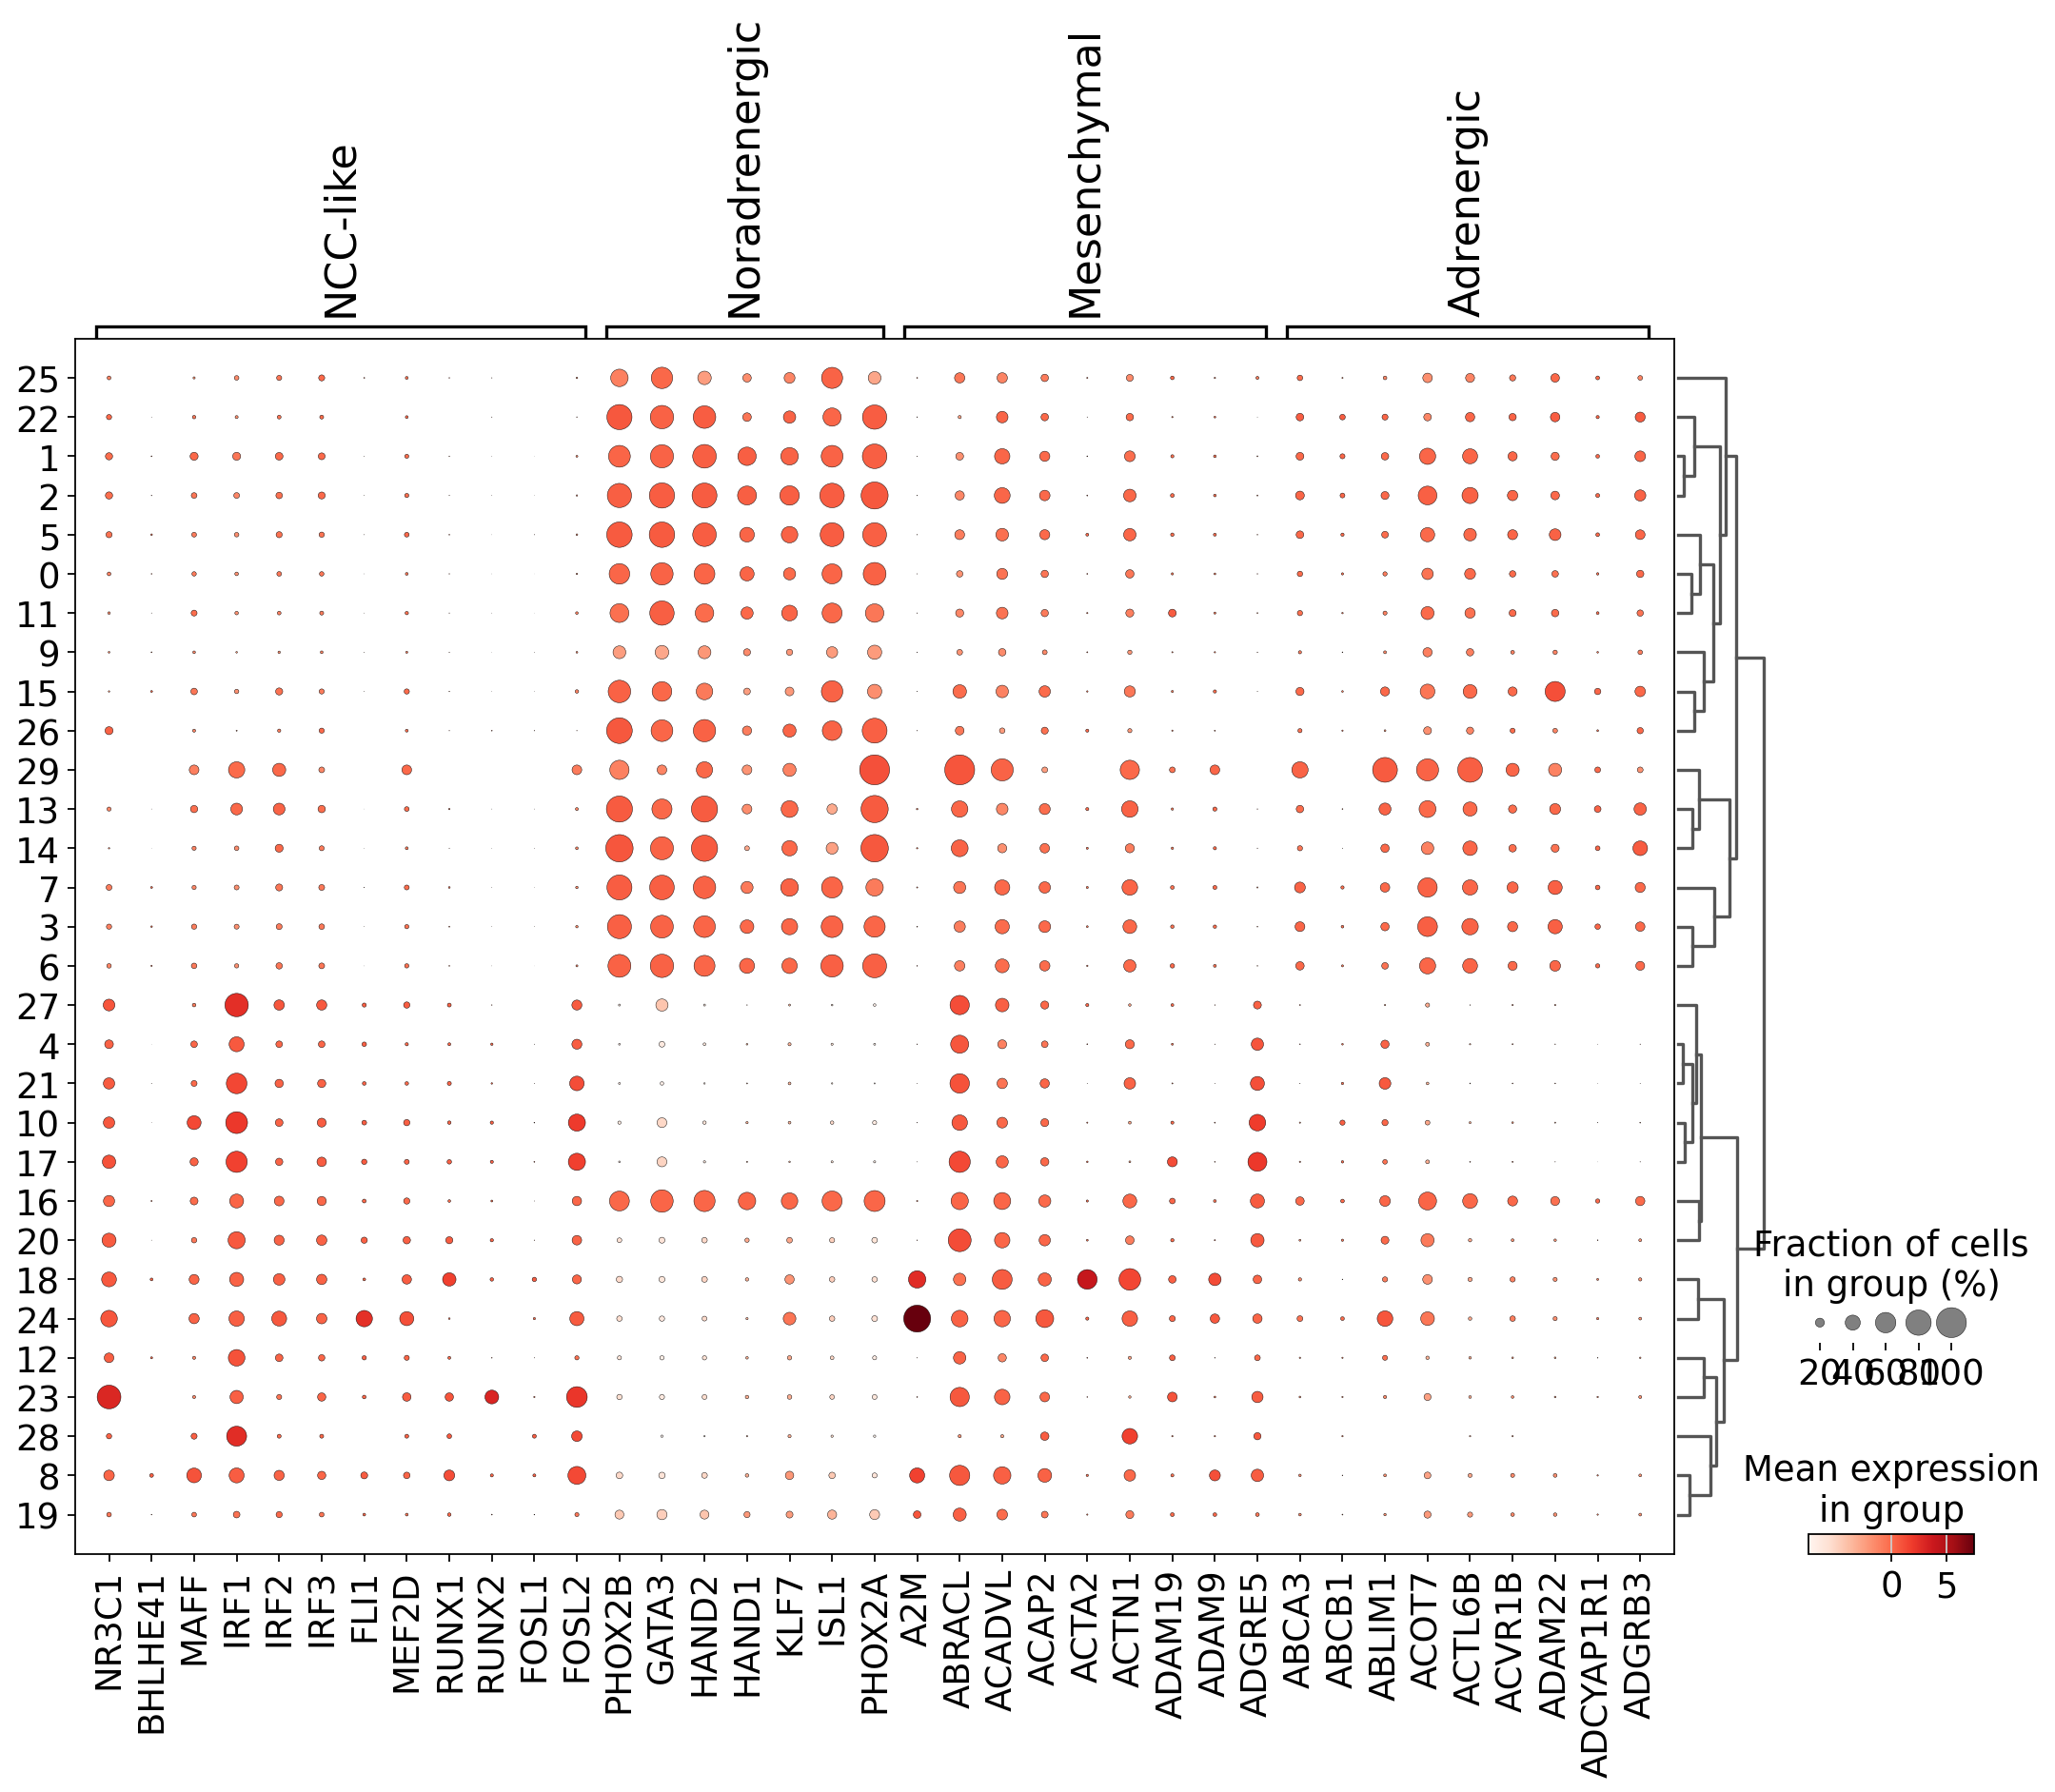

In [18]:
sc.pl.dotplot(sdata, var_names=cell_properties_annotation_dict, groupby='leiden', use_raw=False, dendrogram=True, vcenter=0, save="_cell_properties.svg")

add cell type annotations

In [13]:
# create a dictionary to map cluster to annotation label
cell_type_marker_dict = {
    "25": "NE",
    "22": "NE", 
    "1": "NE", 
    "2": "NE", 
    "5": "NE", 
    "0": "NE", 
    "11": "NE",  
    "9": "NE", 
    "15": "NE",
    "26": "NE",
    "29": "NE", 
    "13": "NE", 
    "14": "NE", 
    "7": "NE",
    "3": "NE",
    "6": "NE",
    "27": "T-cells",
    "4": "T-cells",
    "21": "T-cells",
    "10": "T-cells",
    "17": "T-cells",
    "16": "T-cells",
    "20": "T-cells",
    "18": "Fibroblasts",
    "24": "Endothelium",
    "12": "B-cells",
    "23": "pDC",
    "28": "Myeloid-cells",
    "8": "Myeloid-cells",
    "19": "Myeloid-cells",
}

In [14]:
len(cell_type_marker_dict)

30

In [15]:
# add a new `.obs` column called `cell-type` by mapping clusters to annotation using pandas `map` function
sdata.obs["cell_type"] = sdata.obs["leiden"].map(cell_type_marker_dict).astype('category')

In [16]:
log_data.obs["cell_type"] = sdata.obs["cell_type"]

In [17]:
cdata.obs["cell_type"] = sdata.obs["cell_type"]

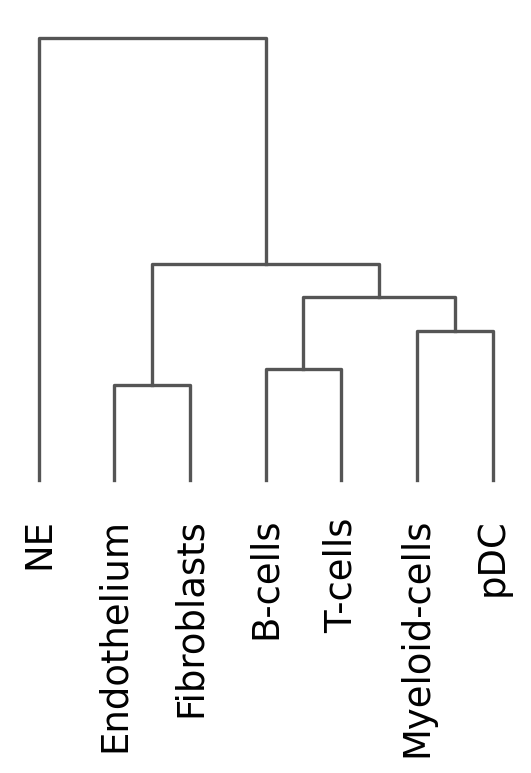

<Axes: >

In [23]:
sc.tl.dendrogram(sdata, groupby='cell_type')
sc.pl.dendrogram(sdata, groupby='cell_type', save=".svg")

In [18]:
cdata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'scrublet'

In [24]:
log_data

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'scrublet'

In [25]:
sdata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'scrublet', 'umap', 'dendrogram_leiden', 'dendrogram_cell_type'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [19]:
cdata.obs["cell_type"]

Cell_barcode
T44_AAACCTGAGAGGTTGC.1         NE
T44_AAACCTGAGAGTGAGA.1         NE
T44_AAACCTGAGGCATGTG.1         NE
T44_AAACCTGAGTGTACCT.1         NE
T44_AAACCTGCAATGCCAT.1         NE
                           ...   
T40_TTTGTCAGTGTCCTCT.1    T-cells
T40_TTTGTCATCACTTATC.1         NE
T40_TTTGTCATCAGGCCCA.1    T-cells
T40_TTTGTCATCTGCAGTA.1    T-cells
T40_TTTGTCATCTGGAGCC.1    T-cells
Name: cell_type, Length: 152182, dtype: category
Categories (7, object): ['B-cells', 'Endothelium', 'Fibroblasts', 'Myeloid-cells', 'NE', 'T-cells', 'pDC']

In [27]:
log_data.obs["cell_type"]

Cell_barcode
T44_AAACCTGAGAGGTTGC.1         NE
T44_AAACCTGAGAGTGAGA.1         NE
T44_AAACCTGAGGCATGTG.1         NE
T44_AAACCTGAGTGTACCT.1         NE
T44_AAACCTGCAATGCCAT.1         NE
                           ...   
T40_TTTGTCAGTGTCCTCT.1    T-cells
T40_TTTGTCATCACTTATC.1         NE
T40_TTTGTCATCAGGCCCA.1    T-cells
T40_TTTGTCATCTGCAGTA.1    T-cells
T40_TTTGTCATCTGGAGCC.1    T-cells
Name: cell_type, Length: 152182, dtype: category
Categories (7, object): ['B-cells', 'Endothelium', 'Fibroblasts', 'Myeloid-cells', 'NE', 'T-cells', 'pDC']

In [26]:
sdata.obs["cell_type"]

Cell_barcode
T44_AAACCTGAGAGGTTGC.1         NE
T44_AAACCTGAGAGTGAGA.1         NE
T44_AAACCTGAGGCATGTG.1         NE
T44_AAACCTGAGTGTACCT.1         NE
T44_AAACCTGCAATGCCAT.1         NE
                           ...   
T40_TTTGTCAGTGTCCTCT.1    T-cells
T40_TTTGTCATCACTTATC.1         NE
T40_TTTGTCATCAGGCCCA.1    T-cells
T40_TTTGTCATCTGCAGTA.1    T-cells
T40_TTTGTCATCTGGAGCC.1    T-cells
Name: cell_type, Length: 152182, dtype: category
Categories (7, object): ['B-cells', 'Endothelium', 'Fibroblasts', 'Myeloid-cells', 'NE', 'T-cells', 'pDC']

categories: B-cells, Endothelium, Fibroblasts, etc.
var_group_labels: Steroidogenic-cortical-cells, Capsular-cells, SCPs, etc.


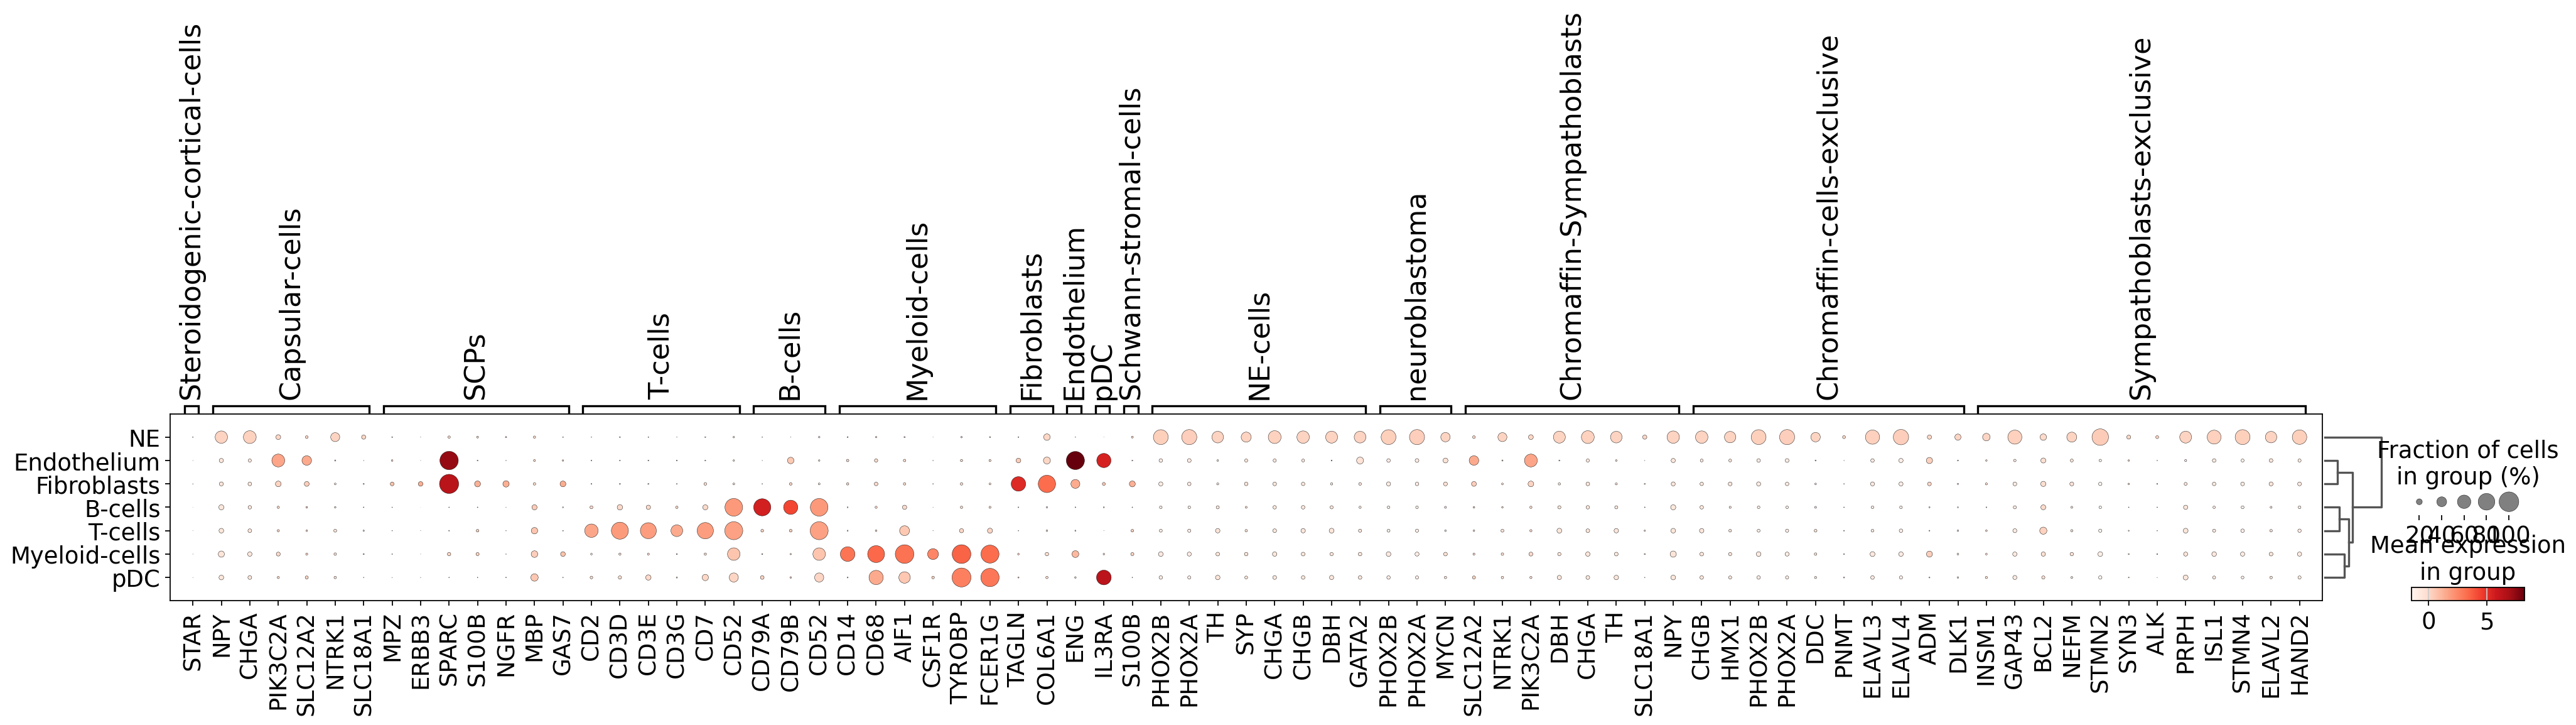

In [29]:
sc.pl.dotplot(sdata, var_names=cell_type_annotation_dict, groupby='cell_type', dendrogram=True, save="cell_type.svg")

In [30]:
# dp = sc.pl.dotplot(cdata, cell_type_annotation_dict, 'cell_type', return_fig=True)
# dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).show()

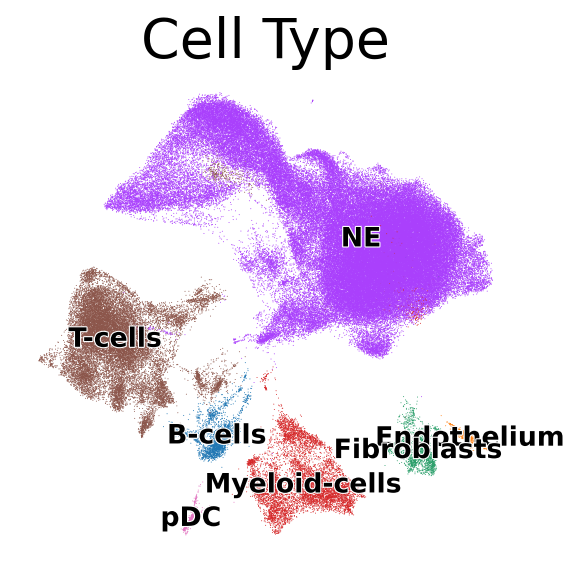

In [31]:
sc.set_figure_params(fontsize=25)
sc.pl.umap(sdata, color='cell_type', legend_loc='on data',
           frameon=False, legend_fontsize=12, legend_fontoutline=1, title="Cell Type", save="_cell_type.svg")

add cell cycle annotations

In [66]:
# # create a dictionary to map cluster to annotation label
# cell_cycle_marker_dict = {
#     "9": "Low",
#     "24": "Low",
#     "0": "Low",
#     "29": "Low",
#     "16": "Low",
#     "17": "Low",
#     "28": "Low",
#     "1": "Low",
#     "14": "Low",
#     "2": "Low",
#     "30": "Low",
#     "7": "Low",
#     "8": "Low",
#     "21": "Low",
#     "6": "Low",
#     "18": "Low",
#     "12": "Low",
#     "3": "Low",
#     "20": "Low",
#     "13": "Low",
#     "23": "Low",
#     "5": "Intermediate",
#     "22": "Intermediate",
#     "11": "Intermediate",
#     "15": "Intermediate",
#     "19": "High",
#     "31": "High",
#     "4": "High",
#     "27": "High",
#     "10": "High",
#     "26": "High",
#     "25": "High",
# }

In [67]:
# len(cell_cycle_marker_dict)

32

In [68]:
# # add a new `.obs` column called `cell-type` by mapping clusters to annotation using pandas `map` function
# cdata.obs["cell_cycle"] = cdata.obs["leiden"].map(cell_cycle_marker_dict).astype('category')

In [69]:
# log_data.obs["cell_cycle"] = cdata.obs["cell_cycle"]

/opt/conda/envs/the-project/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


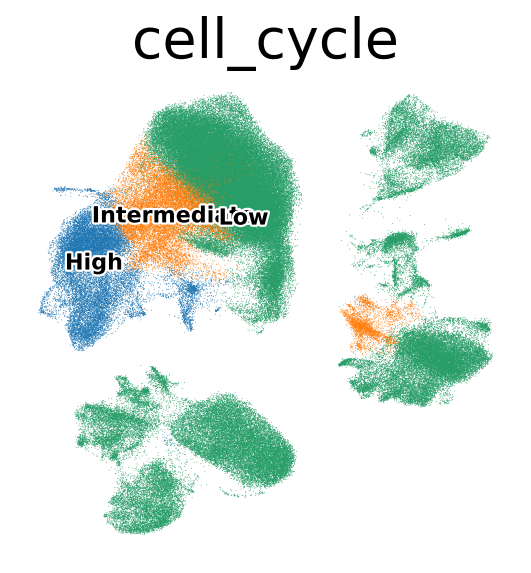

In [70]:
# sc.pl.umap(cdata, color='cell_cycle', legend_loc='on data',
#            frameon=False, legend_fontsize=10, legend_fontoutline=2, save="_cell_cycle.pdf")

In [20]:
cdata.write("cell_type_classified_counts.h5ad")

In [28]:
log_data.write("cell_type_classified_log_data.h5ad")

In [33]:
sdata.write("cell_type_classified.h5ad")